In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

import statsmodels.api as sm

from sklearn.linear_model import LogisticRegression as SkLogisticRegression

from sklearn.preprocessing import SplineTransformer, PolynomialFeatures, StandardScaler

from pygam import LogisticGAM, s

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [4]:
df = pd.read_csv("data/data.csv")
df.head()

,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,purchased
0,49,6720.01,79776.46,3,10,9.00,20.7,1,1,39.25,2,2,0,1,1,9,0,0,0,1,0,0,0,1,0
1,67,2992.49,34566.70,2,9,23.83,15.7,1,0,72.32,3,3,2,2,3,13,1,0,0,0,1,0,0,0,1
2,34,1904.54,22862.84,1,5,21.83,10.7,1,0,109.46,6,6,4,1,6,11,1,0,1,0,0,0,1,0,0
3,73,5105.71,61347.30,2,10,7.53,15.0,0,1,6.57,2,5,3,1,7,18,1,0,0,0,0,0,0,0,0
4,60,4323.43,51861.38,6,20,16.49,8.3,0,1,171.29,4,4,0,0,9,11,1,0,0,0,0,1,0,1,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       6000 non-null   int64  
 1   monthly_income            6000 non-null   float64
 2   annual_income             6000 non-null   float64
 3   website_visits_30d        6000 non-null   int64  
 4   website_visits_90d        6000 non-null   int64  
 5   session_minutes           6000 non-null   float64
 6   discount_pct              6000 non-null   float64
 7   support_tickets_30d       6000 non-null   int64  
 8   premium_member            6000 non-null   int64  
 9   days_since_last_purchase  6000 non-null   float64
 10  cart_items                6000 non-null   int64  
 11  email_opens_30d           6000 non-null   int64  
 12  profile_views_30d         6000 non-null   int64  
 13  social_referrals_30d      6000 non-null   int64  
 14  survey_score       

In [6]:
X = df.drop(columns=['purchased']) 
y = df['purchased']


def standarization(X):
    mean = X.mean()
    std = X.std()
    return (X - mean) / std

X_stand = standarization(X)

In [7]:
X_stand.head()

,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System
0,0.107670,1.627344,1.585479,0.090042,-0.078525,-0.837905,1.291202,0.129127,1.644853,-0.282419,-0.118081,-0.979352,-1.715610,0.357441,-1.566454,-1.332122,-1.271373,-0.299178,-0.485068,2.108057,-0.518384,-0.457867,-0.851766,1.905938
1,1.178128,-0.447462,-0.510153,-0.415811,-0.241326,-0.030031,0.528388,0.129127,-0.607856,0.323274,0.567771,-0.475484,-0.567277,1.558249,-0.871975,-0.258443,0.786420,-0.299178,-0.485068,-0.474291,1.928749,-0.457867,-0.851766,-0.524589
2,-0.784378,-1.053036,-1.052668,-0.921665,-0.892533,-0.138982,-0.234425,0.129127,-0.607856,1.003511,2.625329,1.036121,0.581057,0.357441,0.169742,-0.795282,0.786420,-0.299178,2.061222,-0.474291,-0.518384,-0.457867,1.173836,-0.524589
3,1.534947,0.728795,0.731223,-0.415811,-0.078525,-0.917985,0.421594,-0.920685,1.644853,-0.880968,-0.118081,0.532253,0.006890,0.357441,0.516981,1.083654,0.786420,-0.299178,-0.485068,-0.474291,-0.518384,-0.457867,-0.851766,-0.524589
4,0.761839,0.293363,0.291517,1.607602,1.549491,-0.429882,-0.600576,-0.920685,1.644853,2.135957,1.253624,0.028385,-1.715610,-0.843368,1.211460,-0.795282,0.786420,-0.299178,-0.485068,-0.474291,-0.518384,2.183675,-0.851766,1.905938


In [8]:
X = X_stand.copy()
y = df['purchased']

n = len(df)

np.random.seed(42)
incices = np.random.permutation(n)

X_shuffled = X.iloc[incices]
y_shuffled = y.iloc[incices]

X_train = X_shuffled[:int(0.8*n)]
y_train = y_shuffled[:int(0.8*n)]

X_test = X_shuffled[int(0.8*n):]
y_test = y_shuffled[int(0.8*n):]


print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (4800, 24)
Test set size: (1200, 24)


# Modeling

In [9]:
class LogisticRegression:
    def __init__(self,learning_rate=0.01,num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.costs = []

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.num_iterations):
            # 1. Calculate log-odds
            z = np.dot(X, self.weights) + self.bias
            # 2. Convert log-odds → probabilities
            y_pred = self._sigmoid(z)
            # 3. Calculate cost
            cost = self._cost(y, y_pred)
            self.costs.append(cost)
            # 4. Prediction errors
            error = y_pred - y
            # 5. Gradients
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            # 6. Update parameters
            self.weights -= (self.learning_rate * dw)
            self.bias -= (self.learning_rate * db)

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def _cost(self, y, y_pred):
        epsilon = 1e-15

        y_pred = np.clip(
            y_pred,
            epsilon,
            1 - epsilon
        )

        cost = -(1 / len(y)) * np.sum(
            y * np.log(y_pred)
            +
            (1 - y) * np.log(1 - y_pred)
        )

        return cost


    def predict_proba(self, X):
        z = (np.dot(X, self.weights)+ self.bias)
        return self._sigmoid(z)


    def predict(self, X, threshold=0.5):
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

In [10]:
model = LogisticRegression(learning_rate=0.01, num_iterations=4000)
model.fit(X_train, y_train)

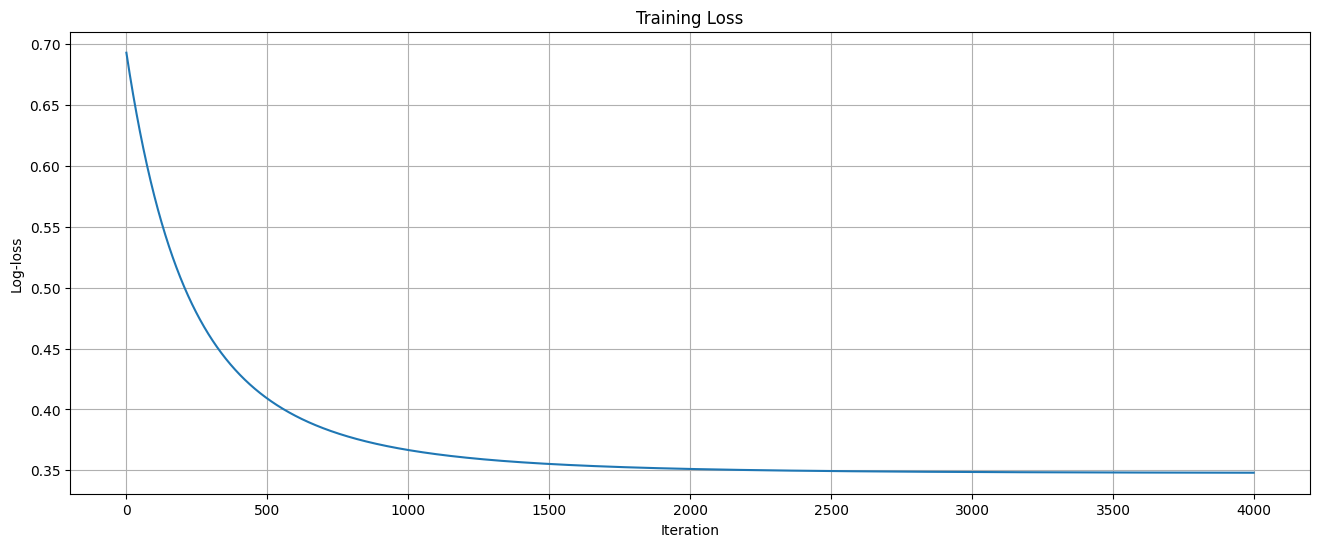

In [11]:
plt.figure(figsize=(16, 6))
plt.plot(model.costs)
plt.xlabel("Iteration")
plt.ylabel("Log-loss")
plt.title("Training Loss")
plt.grid()
plt.show()

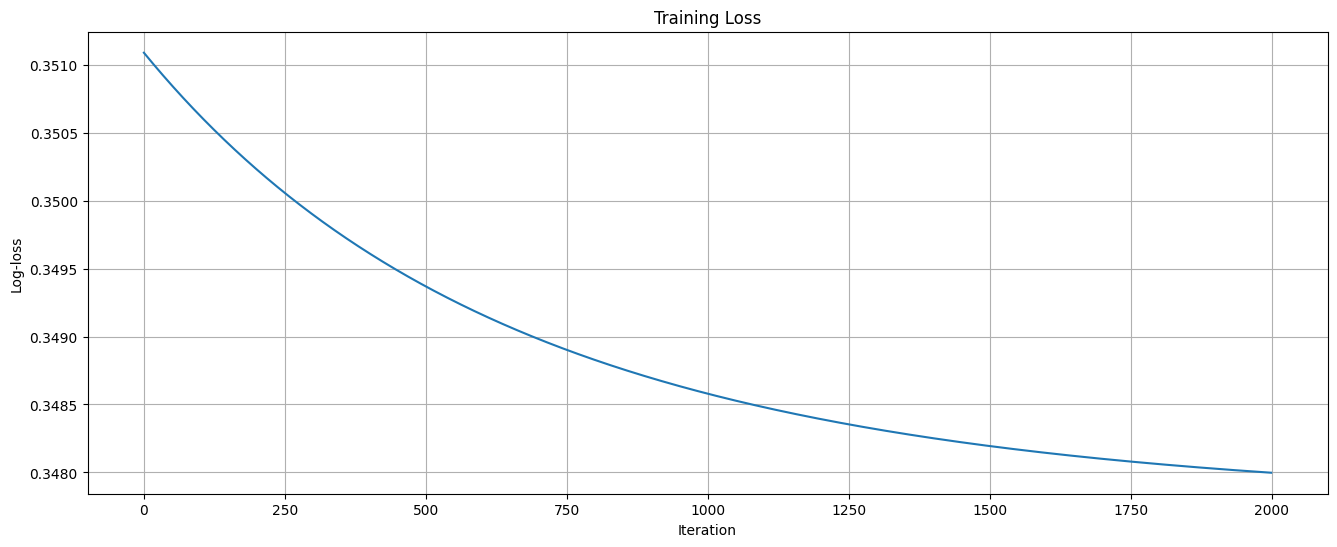

In [12]:
plt.figure(figsize=(16, 6))
plt.plot(model.costs[2000:])
plt.xlabel("Iteration")
plt.ylabel("Log-loss")
plt.title("Training Loss")
plt.grid()
plt.show()

confusion matrix

In [13]:
train_predictions = model.predict(X_train)

In [14]:
TP = np.sum((y_train == 1) & (train_predictions == 1))
TN = np.sum((y_train == 0) & (train_predictions == 0))
FP = np.sum((y_train == 0) & (train_predictions == 1))
FN = np.sum((y_train == 1) & (train_predictions == 0))

print("True Positive:", TP)
print("True Negative:", TN)
print("False Positive:", FP)
print("False Negative:", FN)

True Positive: 25
True Negative: 4160
False Positive: 15
False Negative: 600


In [15]:
train_pred_probs = model.predict_proba(X_train)
train_pred_probs[:5]

array([0.3104756 , 0.15435411, 0.02938249, 0.46240086, 0.17340831])

In [16]:
train_odds = train_pred_probs / (1 - train_pred_probs)
train_odds[:5]

array([0.45027501, 0.18252806, 0.03027195, 0.86012204, 0.20978714])

In [17]:
train_log_odds = np.log(train_odds)
train_log_odds[:5]

array([-0.79789676, -1.70085135, -3.49753365, -0.15068099, -1.56166189])

In [18]:
train_results = pd.DataFrame({
    "Predicted Probability": train_pred_probs,
    "Odds": train_odds,
    "Log-Odds": train_log_odds
})
train_results.head()

,Predicted Probability,Odds,Log-Odds
0,0.310476,0.450275,-0.797897
1,0.154354,0.182528,-1.700851
2,0.029382,0.030272,-3.497534
3,0.462401,0.860122,-0.150681
4,0.173408,0.209787,-1.561662


# Assumptions of Logistic Regression

## Linearity of independent variables and log-odds

###  empirical log-odds plots

selecting data

In [19]:
age_data = pd.DataFrame({
    'age': df['age'].to_numpy(),
    'purchased': df['purchased'].to_numpy()
})
age_data.head()


,age,purchased
0,49,0
1,67,1
2,34,0
3,73,0
4,60,0


dividing the feature into bins

In [20]:
age_data['bin'] = pd.qcut(
    age_data['age'],
    q=10,
    duplicates='drop'
)
age_data.head(10)

,age,purchased,bin
0,49,0,"(48.0, 53.0]"
1,67,1,"(65.0, 70.0]"
2,34,0,"(30.0, 36.0]"
3,73,0,"(70.0, 75.0]"
4,60,0,"(59.0, 65.0]"
5,47,0,"(42.0, 48.0]"
6,56,0,"(53.0, 59.0]"
7,45,0,"(42.0, 48.0]"
8,23,0,"(17.999, 23.0]"
9,25,0,"(23.0, 30.0]"


In [21]:
age_summary = (
    age_data
    .groupby('bin', observed=True)
    .agg(
        mean_age=('age', 'mean'),
        probability=('purchased', 'mean')
    )
)

In [22]:
age_summary

,mean_age,probability
bin,,
"(17.999, 23.0]",20.437299,0.009646
"(23.0, 30.0]",26.893082,0.045597
"(30.0, 36.0]",33.360068,0.107509
"(36.0, 42.0]",39.443103,0.165517
"(42.0, 48.0]",45.359352,0.237113
"(48.0, 53.0]",51.005254,0.248687
"(53.0, 59.0]",56.315299,0.212687
"(59.0, 65.0]",62.481203,0.154887
"(65.0, 70.0]",67.878261,0.125217


In [23]:
age_summary['odds'] = (
    age_summary['probability'] / (1 - age_summary['probability'])
)
age_summary

,mean_age,probability,odds
bin,,,
"(17.999, 23.0]",20.437299,0.009646,0.009740
"(23.0, 30.0]",26.893082,0.045597,0.047776
"(30.0, 36.0]",33.360068,0.107509,0.120459
"(36.0, 42.0]",39.443103,0.165517,0.198347
"(42.0, 48.0]",45.359352,0.237113,0.310811
"(48.0, 53.0]",51.005254,0.248687,0.331002
"(53.0, 59.0]",56.315299,0.212687,0.270142
"(59.0, 65.0]",62.481203,0.154887,0.183274
"(65.0, 70.0]",67.878261,0.125217,0.143141


In [24]:
age_summary['log_odds'] = np.log(age_summary['odds'])
age_summary

,mean_age,probability,odds,log_odds
bin,,,,
"(17.999, 23.0]",20.437299,0.009646,0.009740,-4.631487
"(23.0, 30.0]",26.893082,0.045597,0.047776,-3.041233
"(30.0, 36.0]",33.360068,0.107509,0.120459,-2.116447
"(36.0, 42.0]",39.443103,0.165517,0.198347,-1.617737
"(42.0, 48.0]",45.359352,0.237113,0.310811,-1.168571
"(48.0, 53.0]",51.005254,0.248687,0.331002,-1.105630
"(53.0, 59.0]",56.315299,0.212687,0.270142,-1.308807
"(59.0, 65.0]",62.481203,0.154887,0.183274,-1.696773
"(65.0, 70.0]",67.878261,0.125217,0.143141,-1.943924


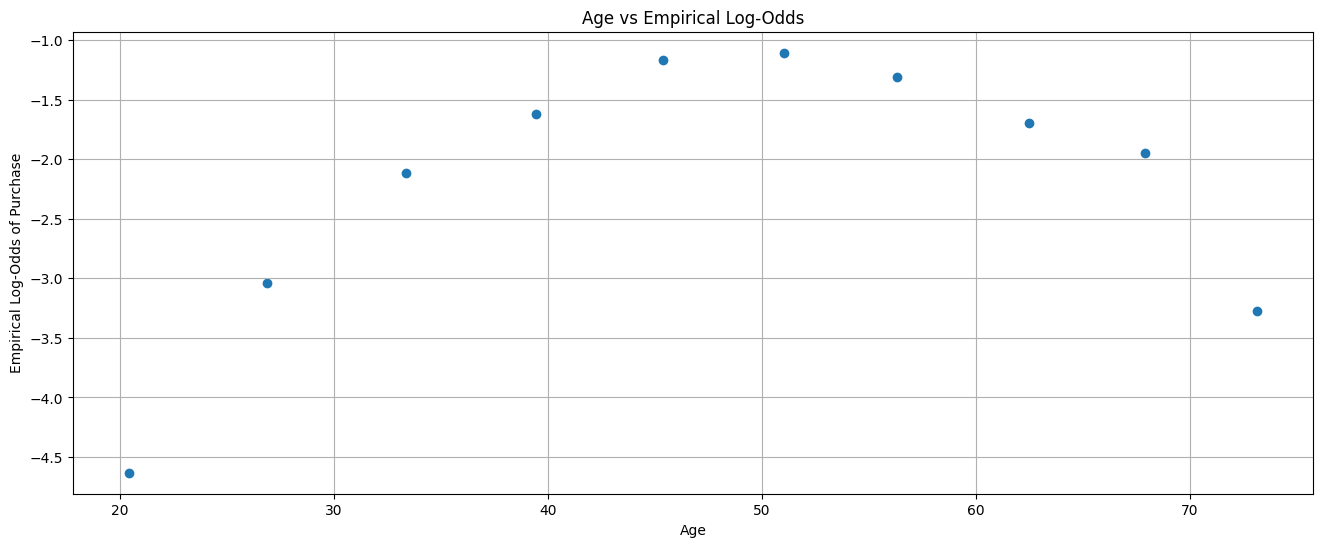

In [25]:
plt.figure(figsize=(16, 6))

plt.scatter(
    age_summary['mean_age'],
    age_summary['log_odds']
)

plt.xlabel('Age')
plt.ylabel('Empirical Log-Odds of Purchase')
plt.title('Age vs Empirical Log-Odds')
plt.grid()

plt.show()

Empirical log-odds diagnostic for age: the relationship is visiably nonlinear. Log-odds increase from youngr ages to to approximately middle age and then decrease at olrder ages, producing an inverted-U pattern. Therefore, presenting age with only singe linear term may violate the Logistic Regression linearity-of-log-odds assumption.

### Box-Tidwell test

selecting feature and target

In [26]:
age_bt = pd.DataFrame({
    "age":df.loc[X_train.index, 'age'],
    "purchased":y_train
})

age_bt.head()

,age,purchased
1782,65,0
3917,18,0
221,21,0
2135,67,1
5224,60,0


min value must be greater than 0

In [27]:
age_bt['age'].min()

np.int64(18)

creating the Box-Tidwell term `X*In(X)` = `age*In(age)` = `age * np.log(age)`

In [28]:
age_bt['age_log_age'] = (
    age_bt['age'] * np.log(age_bt['age'])
)

age_bt.head()

,age,purchased,age_log_age
1782,65,0,271.335173
3917,18,0,52.026692
221,21,0,63.934971
2135,67,1,281.714405
5224,60,0,245.660674


`p-value`

In [29]:
# selecting predictors
X_box = age_bt[
    ['age', 'age_log_age']
]

# selecting target
y_box = age_bt['purchased']

# adding interceot
X_box = sm.add_constant(X_box)

# Fitting Logistic Regression
box_model = sm.Logit(y_box, X_box).fit()

box_model.summary()

Optimization terminated successfully.
         Current function value: 0.353266
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              purchased   No. Observations:                 4800
Model:                          Logit   Df Residuals:                     4797
Method:                           MLE   Df Model:                            2
Date:                Mon, 28 Sep 2026   Pseudo R-squ.:                 0.08665
Time:                        07:01:11   Log-Likelihood:                -1695.7
converged:                       True   LL-Null:                       -1856.6
Covariance Type:            nonrobust   LLR p-value:                 1.353e-70
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -18.5761      1.234    -15.056      0.000     -20.994     -16.158
age             1.7214      0.125     13.801      0.000       1.477       1.966
age_log_age    -0.3509      0.025    -13.787      0.000      -0.401      -0.301
===============================================================================
"""

In [30]:
p_value = box_model.pvalues['age_log_age']
p_value

np.float64(3.038783575673153e-43)

In [31]:
# 9. Decision
alpha = 0.05

if p_value < alpha:
    print(
        "Reject H0: evidence that age is "
        "nonlinear with the log-odds."
    )
else:
    print(
        "Fail to reject H0: no strong evidence "
        "against linearity."
    )

Reject H0: evidence that age is nonlinear with the log-odds.


### Spline plots

1-step: selecting row data

In [32]:
age_train = df.loc[X_train.index, 'age'].to_numpy().reshape(-1, 1)
y_age = y_train.to_numpy()

2-step: Initializing SplineTransormer

In [33]:
spline = SplineTransformer(
    n_knots=5, # gives the curve several places where it can change its behavior
    degree=3, # creates cubic spline pieces, allowing smooth curvature
    include_bias=False # we let Logistic Regression handle the intercept
)

3-step: Transforming the feature with SplineTransformer

In [34]:
age_spline = spline.fit_transform(age_train)

In [35]:
age_train.shape

(4800, 1)

In [36]:
age_spline.shape

(4800, 6)

In [37]:
age_spline[:1]

array([[0.        , 0.        , 0.        , 0.05759757, 0.59098076,
        0.34700016]])

4-step: Training LogisticRegression model with the transformed feature

In [38]:
spline_model = SkLogisticRegression(
    C=1e6,
    max_iter=5000
)
spline_model.fit(age_spline, y_age)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1000000.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

5-step: generating evenly spaced ages for visualization

In [39]:
age_grid = np.linspace(
    age_train.min(),
    age_train.max(),
    300
).reshape(-1, 1)
age_grid[:5]

array([[18.        ],
       [18.19063545],
       [18.3812709 ],
       [18.57190635],
       [18.76254181]])

6-step: converting these 300 ages into the same spline basis features that were used during training

In [40]:
age_grid_spline = spline.transform(age_grid)


7-step: Asking the fitted logistic regression model for the log-odds at each of these ages

In [41]:
spline_log_odds = spline_model.decision_function(
    age_grid_spline
)
spline_log_odds[:10]

array([-4.42933658, -4.42276567, -4.41525129, -4.40681079, -4.39746153,
       -4.38722087, -4.37610618, -4.36413482, -4.35132413, -4.33769149])

8-step: plotting the spline curve

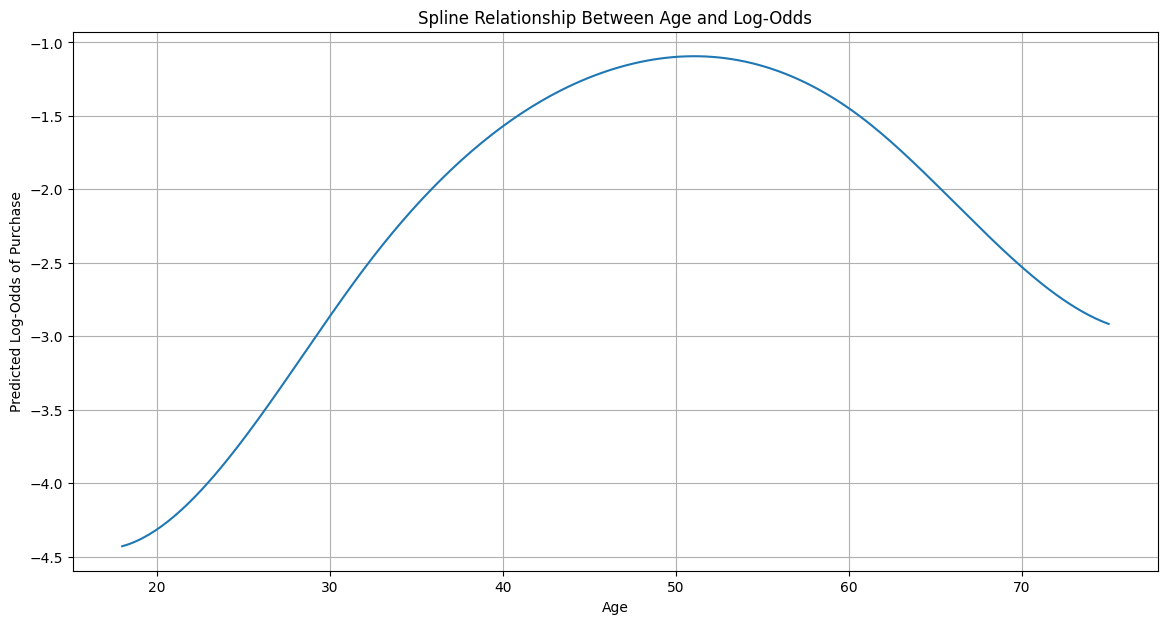

In [42]:
plt.figure(figsize=(14, 7))

plt.plot(
    age_grid.ravel(),
    spline_log_odds
)

plt.xlabel('Age')
plt.ylabel('Predicted Log-Odds of Purchase')
plt.title('Spline Relationship Between Age and Log-Odds')

plt.grid()
plt.show()

9-step: comparing with ordinary Logistic Regression

In [43]:
linear_model = SkLogisticRegression(
    C=1e6,
    max_iter=5000
)
linear_model.fit(age_train, y_age)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1000000.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [44]:
linear_log_odds = linear_model.decision_function(
    age_grid
)

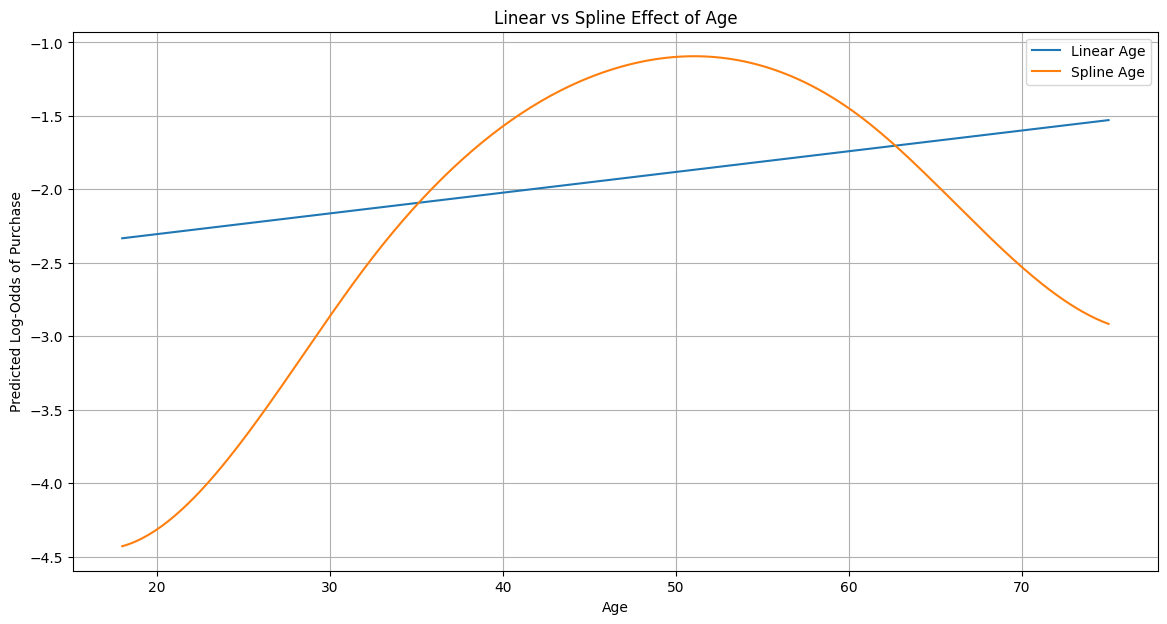

In [45]:
plt.figure(figsize=(14, 7))

plt.plot(
    age_grid.ravel(),
    linear_log_odds,
    label='Linear Age'
)

plt.plot(
    age_grid.ravel(),
    spline_log_odds,
    label='Spline Age'
)

plt.xlabel('Age')
plt.ylabel('Predicted Log-Odds of Purchase')
plt.title('Linear vs Spline Effect of Age')

plt.legend()
plt.grid()
plt.show()

In [46]:
df.head()

,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,purchased
0,49,6720.01,79776.46,3,10,9.00,20.7,1,1,39.25,2,2,0,1,1,9,0,0,0,1,0,0,0,1,0
1,67,2992.49,34566.70,2,9,23.83,15.7,1,0,72.32,3,3,2,2,3,13,1,0,0,0,1,0,0,0,1
2,34,1904.54,22862.84,1,5,21.83,10.7,1,0,109.46,6,6,4,1,6,11,1,0,1,0,0,0,1,0,0
3,73,5105.71,61347.30,2,10,7.53,15.0,0,1,6.57,2,5,3,1,7,18,1,0,0,0,0,0,0,0,0
4,60,4323.43,51861.38,6,20,16.49,8.3,0,1,171.29,4,4,0,0,9,11,1,0,0,0,0,1,0,1,0


### GAM 

In [47]:
df.head()

,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,purchased
0,49,6720.01,79776.46,3,10,9.00,20.7,1,1,39.25,2,2,0,1,1,9,0,0,0,1,0,0,0,1,0
1,67,2992.49,34566.70,2,9,23.83,15.7,1,0,72.32,3,3,2,2,3,13,1,0,0,0,1,0,0,0,1
2,34,1904.54,22862.84,1,5,21.83,10.7,1,0,109.46,6,6,4,1,6,11,1,0,1,0,0,0,1,0,0
3,73,5105.71,61347.30,2,10,7.53,15.0,0,1,6.57,2,5,3,1,7,18,1,0,0,0,0,0,0,0,0
4,60,4323.43,51861.38,6,20,16.49,8.3,0,1,171.29,4,4,0,0,9,11,1,0,0,0,0,1,0,1,0


1-Step: Selecting Data

In [48]:
gam_feaures = [
    'age',
    'monthly_income',
    'session_minutes'
]


In [49]:
X_gam = df.loc[X_train.index, gam_feaures].to_numpy()
y_gam = y_train.to_numpy()

In [50]:
X_gam.shape

(4800, 3)

2-Step: Defining the GAM 
- s(0) means -> smooth function for the first column ()
- s(1) means -> smooth function for the second column ()
- s(2) means -> smooth function for the third column ()

In [51]:
gam = LogisticGAM(
    s(0) + 
    s(1) + 
    s(2)
)

In [52]:
gam.fit(X_gam, y_gam)

LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=100, 
   terms=s(0) + s(1) + s(2) + intercept, tol=0.0001, verbose=False)

3-Step: Plotting 

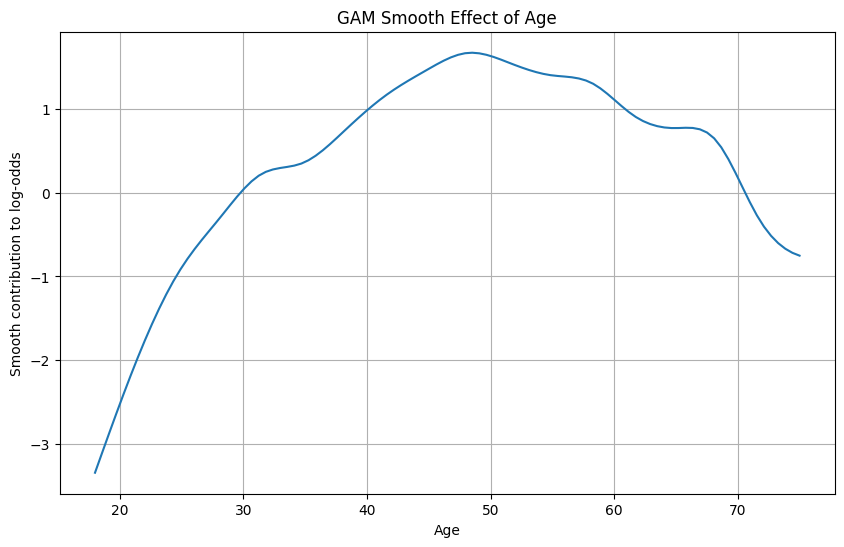

In [53]:
# Plotting the function of age feature
XX = gam.generate_X_grid(term=0) # term=0 refers to s(0)=age
age_effect = gam.partial_dependence(
    term=0,
    X=XX
)

plt.figure(figsize=(10, 6))
plt.plot(
    XX[:,0],
    age_effect
)
plt.xlabel("Age")
plt.ylabel("Smooth contribution to log-odds")
plt.title("GAM Smooth Effect of Age")
plt.grid()
plt.show()

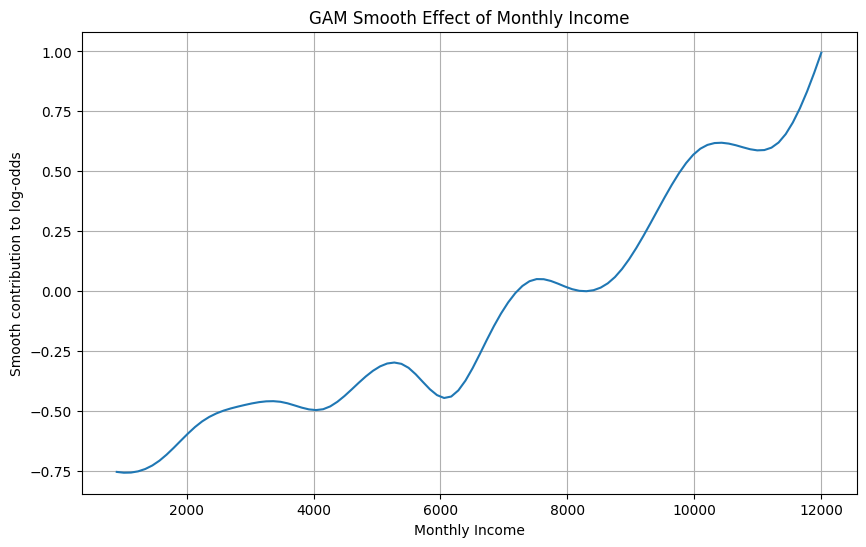

In [54]:
# ploting the function of monthly income 
XX = gam.generate_X_grid(term=1)
income_effect = gam.partial_dependence(
    term=1,
    X=XX
)

plt.figure(figsize=(10, 6))
plt.plot(
    XX[:, 1],
    income_effect
)
plt.xlabel("Monthly Income")
plt.ylabel("Smooth contribution to log-odds")
plt.title("GAM Smooth Effect of Monthly Income")
plt.grid()
plt.show()

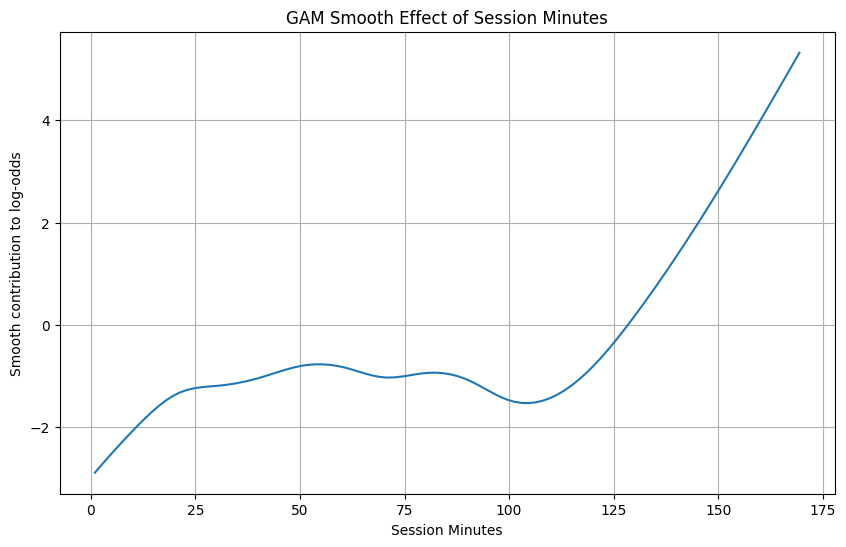

In [55]:
# plotting the function of session_minutes
XX = gam.generate_X_grid(term=2)
session_effect = gam.partial_dependence(
    term=2,
    X=XX
)

plt.figure(figsize=(10, 6))
plt.plot(
    XX[:, 2],
    session_effect
)
plt.xlabel('Session Minutes')
plt.ylabel('Smooth contribution to log-odds')
plt.title('GAM Smooth Effect of Session Minutes')

plt.grid()
plt.show()

### Polynomial term

1-step: selecting data

In [56]:
age_train = df.loc[X_train.index, 'age'].to_numpy().reshape(-1, 1)
y_age = y_train.to_numpy()

In [57]:
age_train.shape

(4800, 1)

2-training ordinary logistic regression model

In [58]:
linear_model = SkLogisticRegression(
    C=1e6,
    max_iter=5000
)
linear_model.fit(age_train, y_age)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1000000.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

3-creating polynomial features

In [59]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

In [60]:
age_poly = poly.fit_transform(age_train)

In [61]:
age_poly.shape

(4800, 2)

In [62]:
age_poly[:5]

array([[  65., 4225.],
       [  18.,  324.],
       [  21.,  441.],
       [  67., 4489.],
       [  60., 3600.]])

In [63]:
poly.get_feature_names_out(['age'])

array(['age', 'age^2'], dtype=object)

4-step: Training Logistic Regression model by age and age²

In [64]:
poly_model = SkLogisticRegression(
    C=1e6,
    max_iter=5000
)
poly_model.fit(age_poly, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1000000.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

4-step: Plotting decision functions of the models

In [65]:
age_grid = np.linspace(
    age_train.min(),
    age_train.max(),
    300
).reshape(-1, 1)

In [66]:
# getting ordinary logistic regression log-odds
linear_log_odds = linear_model.decision_function(age_grid)

In [67]:
# transforming those age in age and age_square
age_grid_poly = poly.transform(age_grid)

In [68]:
# getting polynomial logistic regression log-odds
poly_log_odds = poly_model.decision_function(age_grid_poly)

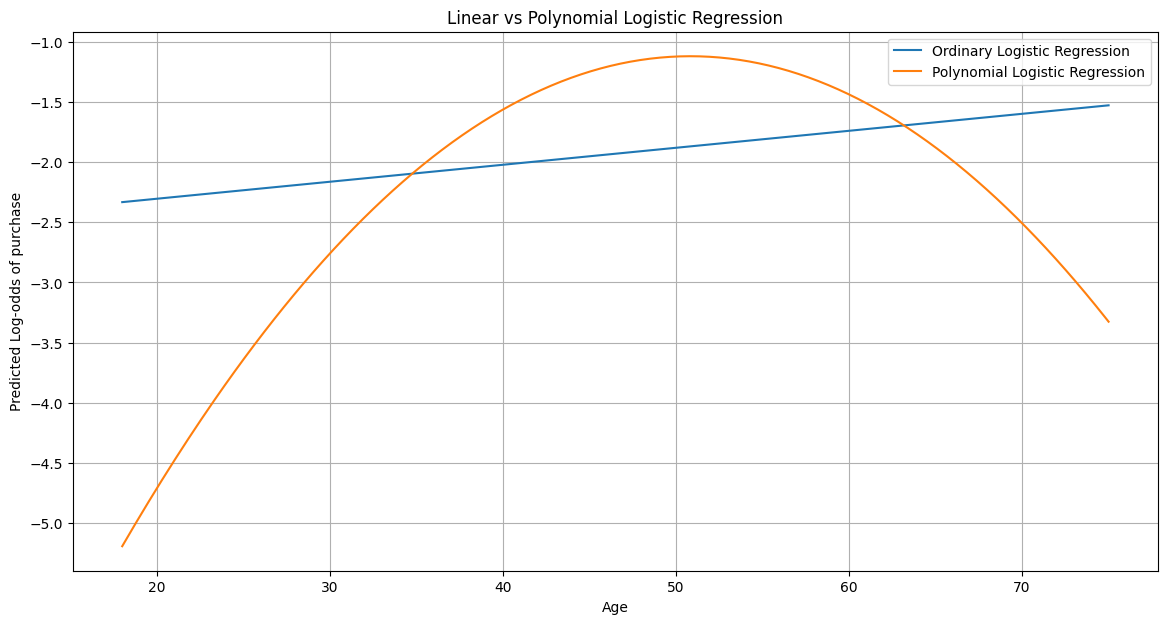

In [69]:
plt.figure(figsize=(14, 7))

plt.plot(
    age_grid.ravel(),
    linear_log_odds,
    label="Ordinary Logistic Regression"
)

plt.plot(
    age_grid.ravel(),
    poly_log_odds,
    label='Polynomial Logistic Regression'
)

plt.xlabel("Age")
plt.ylabel("Predicted Log-odds of purchase")
plt.title("Linear vs Polynomial Logistic Regression")

plt.legend()
plt.grid()
plt.show()

In [70]:
age_summary['mean_age']
age_summary['log_odds']

bin
(17.999, 23.0]   -4.631487
(23.0, 30.0]     -3.041233
(30.0, 36.0]     -2.116447
(36.0, 42.0]     -1.617737
(42.0, 48.0]     -1.168571
(48.0, 53.0]     -1.105630
(53.0, 59.0]     -1.308807
(59.0, 65.0]     -1.696773
(65.0, 70.0]     -1.943924
(70.0, 75.0]     -3.277145
Name: log_odds, dtype: float64

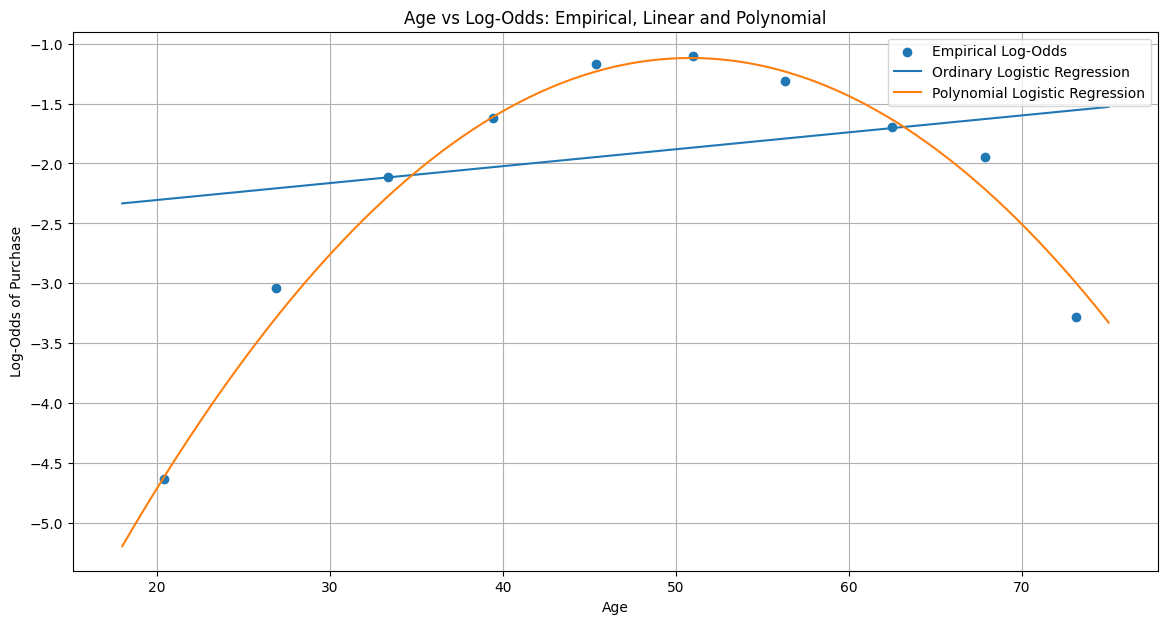

In [71]:
plt.figure(figsize=(14, 7))

plt.scatter(
    age_summary['mean_age'],
    age_summary['log_odds'],
    label='Empirical Log-Odds'
)

plt.plot(
    age_grid.ravel(),
    linear_log_odds,
    label='Ordinary Logistic Regression'
)

plt.plot(
    age_grid.ravel(),
    poly_log_odds,
    label='Polynomial Logistic Regression'
)

plt.xlabel('Age')
plt.ylabel('Log-Odds of Purchase')
plt.title(
    'Age vs Log-Odds: Empirical, Linear and Polynomial'
)

plt.legend()
plt.grid()

plt.show()

### Partial-Effect Plots

In [72]:
df.head()

,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,purchased
0,49,6720.01,79776.46,3,10,9.00,20.7,1,1,39.25,2,2,0,1,1,9,0,0,0,1,0,0,0,1,0
1,67,2992.49,34566.70,2,9,23.83,15.7,1,0,72.32,3,3,2,2,3,13,1,0,0,0,1,0,0,0,1
2,34,1904.54,22862.84,1,5,21.83,10.7,1,0,109.46,6,6,4,1,6,11,1,0,1,0,0,0,1,0,0
3,73,5105.71,61347.30,2,10,7.53,15.0,0,1,6.57,2,5,3,1,7,18,1,0,0,0,0,0,0,0,0
4,60,4323.43,51861.38,6,20,16.49,8.3,0,1,171.29,4,4,0,0,9,11,1,0,0,0,0,1,0,1,0


In [73]:
part_effect_X = df.loc[:,['age','monthly_income','annual_income']]
part_effect_y = df['purchased']

In [74]:
part_effect_model = SkLogisticRegression(
    C=1e6,
    max_iter=5000
)

In [75]:
part_effect_model.fit(
    part_effect_X,
    part_effect_y
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1000000.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

we want to measure the partial effect of `age`

1-step: choosing the fixed valuesfor the other two features. a common simple choice is their medians

In [76]:
monthly_income_fixed = part_effect_X['monthly_income'].median()
annual_income_fixed = part_effect_X['annual_income'].median()

2-step: creating a clean range values from the youngest to the oldest

In [77]:
age_values = np.linspace(
    part_effect_X['age'].min(),
    part_effect_X['age'].max(),
    100
)

3-step: creating an artificial dataset

In [78]:
X_age_effect = pd.DataFrame({
    'age':age_values,
    'monthly_income':monthly_income_fixed,
    'annual_income':annual_income_fixed
})
X_age_effect.head()

,age,monthly_income,annual_income
0,18.000000,3419.64,41080.505
1,18.575758,3419.64,41080.505
2,19.151515,3419.64,41080.505
3,19.727273,3419.64,41080.505
4,20.303030,3419.64,41080.505


4-step: giving these new rows to the trained Logistic Regression mode

In [79]:
age_log_odds = part_effect_model.decision_function(
    X_age_effect
)

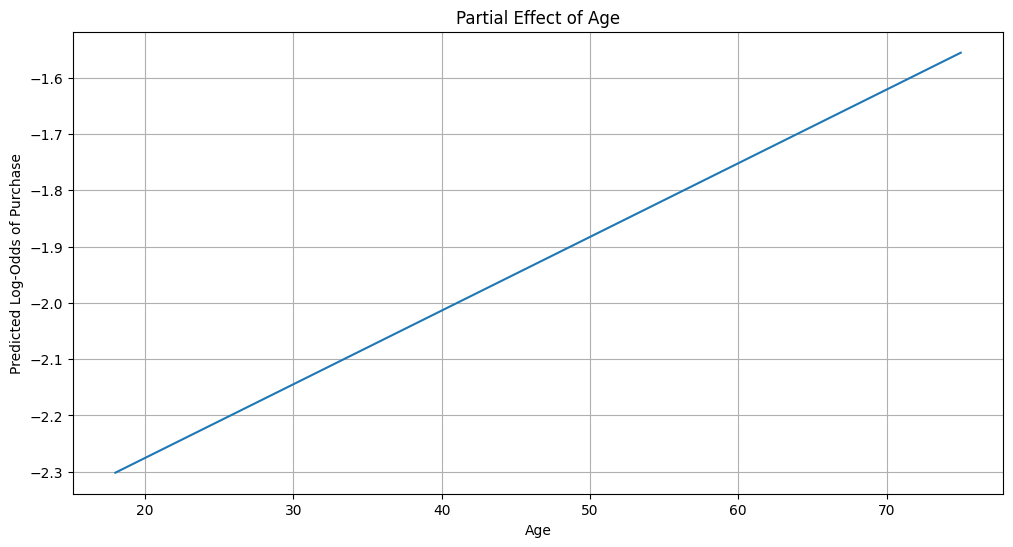

In [80]:
plt.figure(figsize=(12, 6))

plt.plot(
    age_values,
    age_log_odds
)

plt.xlabel('Age')
plt.ylabel('Predicted Log-Odds of Purchase')
plt.title('Partial Effect of Age')

plt.grid()
plt.show()

### Residual Diagnostics

In [81]:
df.head()

,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,purchased
0,49,6720.01,79776.46,3,10,9.00,20.7,1,1,39.25,2,2,0,1,1,9,0,0,0,1,0,0,0,1,0
1,67,2992.49,34566.70,2,9,23.83,15.7,1,0,72.32,3,3,2,2,3,13,1,0,0,0,1,0,0,0,1
2,34,1904.54,22862.84,1,5,21.83,10.7,1,0,109.46,6,6,4,1,6,11,1,0,1,0,0,0,1,0,0
3,73,5105.71,61347.30,2,10,7.53,15.0,0,1,6.57,2,5,3,1,7,18,1,0,0,0,0,0,0,0,0
4,60,4323.43,51861.38,6,20,16.49,8.3,0,1,171.29,4,4,0,0,9,11,1,0,0,0,0,1,0,1,0


1-step: Selecting data

In [82]:
features = ['age', 'monthly_income', 'annual_income']

X_resid = df.loc[X_train.index, features]
y_resid = df.loc[X_train.index, 'purchased']

2-step: Training Ordinary Logistic Regression model

In [83]:
resid_model = SkLogisticRegression(
    C=1e6,
    max_iter=5000
)
resid_model.fit(
    X_resid,
    y_resid
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1000000.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

3-Step: Predicting probabilities of y=1

In [84]:
p_hat = resid_model.predict_proba(X_resid)[:, 1] # why [:, 1], because predict_prob restults two rows [P(y=0), P(y=1)]. We need P(y=1)

4-step: Calculating residuals

In [85]:
raw_residuals = y_resid - p_hat

5-step: Pearson residual
` rᵢ = (yᵢ - p̂ᵢ) / √(p̂ᵢ(1 - p̂ᵢ))`

In [86]:
pearson_residuals = (
    (y_resid - p_hat) / 
    np.sqrt(p_hat * (1 - p_hat))
)


In [87]:
residual_data = pd.DataFrame({
    "age":X_resid['age'].to_numpy(),
    'predicted_probability':p_hat,
    'pearson_residual':pearson_residuals
})
residual_data.head()

,age,predicted_probability,pearson_residual
1782,65,0.157107,-0.431729
3917,18,0.084056,-0.302936
221,21,0.095575,-0.325077
2135,67,0.302395,1.518860
5224,60,0.173338,-0.457913


6-step: plotting

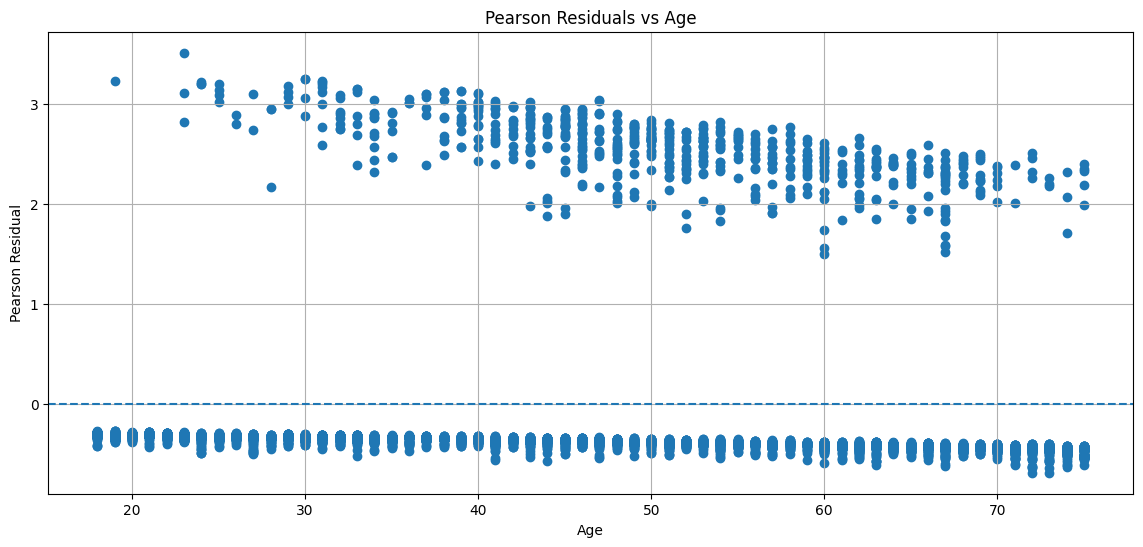

In [88]:
plt.figure(figsize=(14, 6))

plt.scatter(
    residual_data['age'],
    residual_data['pearson_residual'],
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Age')
plt.ylabel('Pearson Residual')
plt.title('Pearson Residuals vs Age')

plt.grid()
plt.show()

In [89]:
residual_data['age_bin'] = pd.qcut(
    residual_data['age'],
    q=10,
    duplicates='drop'
)

residual_summary = (
    residual_data
    .groupby('age_bin', observed=True)
    .agg(
        mean_age=('age', 'mean'),
        mean_residual=('pearson_residual', 'mean')
    )
)
residual_data.head()

,age,predicted_probability,pearson_residual,age_bin
1782,65,0.157107,-0.431729,"(60.0, 65.0]"
3917,18,0.084056,-0.302936,"(17.999, 23.0]"
221,21,0.095575,-0.325077,"(17.999, 23.0]"
2135,67,0.302395,1.518860,"(65.0, 70.0]"
5224,60,0.173338,-0.457913,"(53.0, 60.0]"


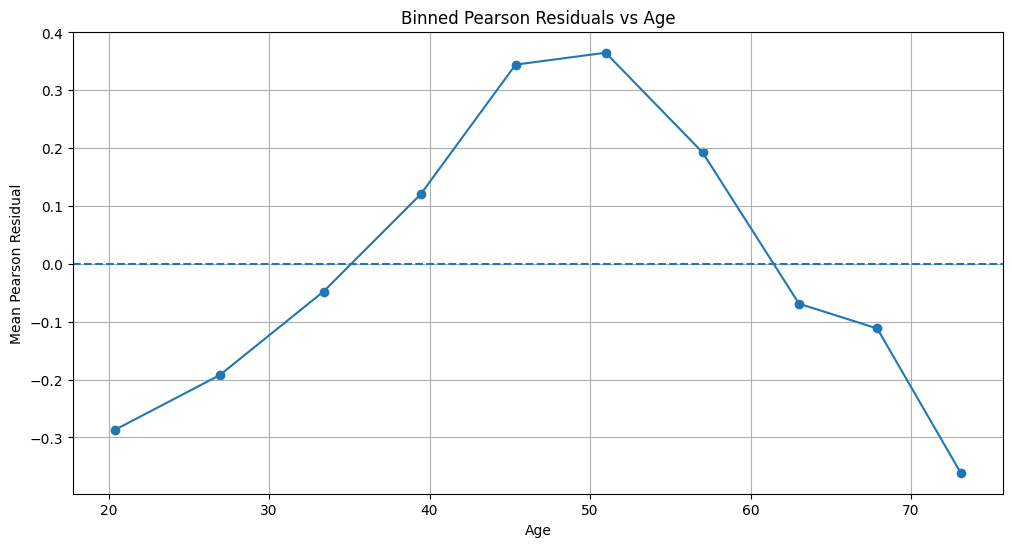

In [90]:
plt.figure(figsize=(12, 6))

plt.scatter(
    residual_summary['mean_age'],
    residual_summary['mean_residual']
)

plt.plot(
    residual_summary['mean_age'],
    residual_summary['mean_residual']
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Age')
plt.ylabel('Mean Pearson Residual')
plt.title('Binned Pearson Residuals vs Age')

plt.grid()
plt.show()

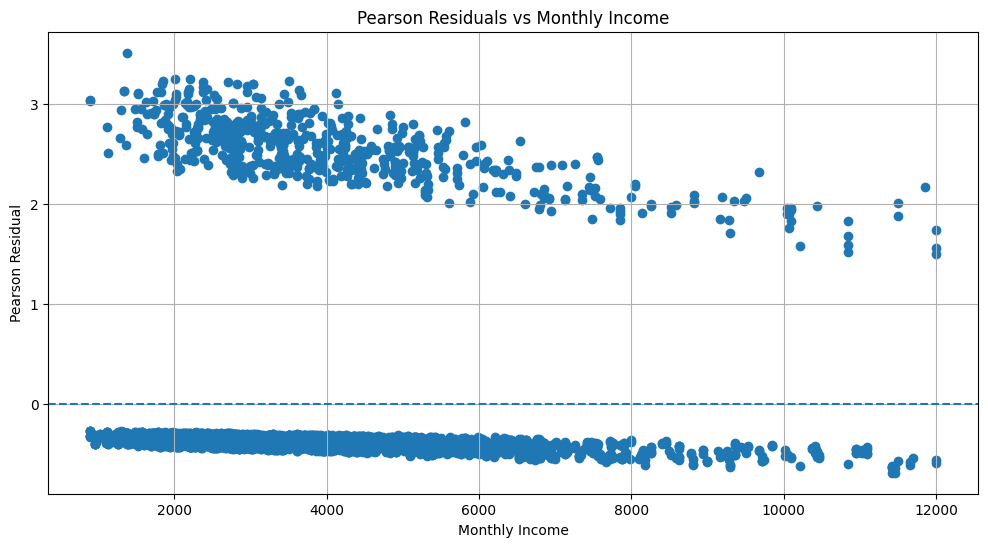

In [91]:
plt.figure(figsize=(12, 6))

plt.scatter(
    X_resid['monthly_income'],
    pearson_residuals,
)

plt.axhline(0, linestyle='--')

plt.xlabel('Monthly Income')
plt.ylabel('Pearson Residual')
plt.title('Pearson Residuals vs Monthly Income')

plt.grid()
plt.show()

In [92]:
income_resid = pd.DataFrame({
    'monthly_income': X_resid['monthly_income'].to_numpy(),
    'pearson_residual': pearson_residuals
})

income_resid['bin'] = pd.qcut(
    income_resid['monthly_income'],
    q=10,
    duplicates='drop'
)

income_summary = (
    income_resid
    .groupby('bin', observed=True)
    .agg(
        mean_income=('monthly_income', 'mean'),
        mean_residual=('pearson_residual', 'mean')
    )
)

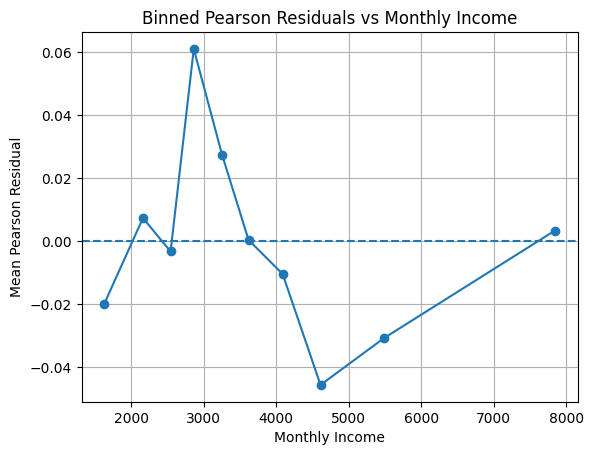

In [93]:
plt.plot(
    income_summary['mean_income'],
    income_summary['mean_residual'],
    marker='o'
)

plt.axhline(0, linestyle='--')

plt.xlabel('Monthly Income')
plt.ylabel('Mean Pearson Residual')
plt.title('Binned Pearson Residuals vs Monthly Income')

plt.grid()
plt.show()

## Independence of Observations

### Duplicated observations

In [94]:
df = pd.read_csv("data/datav2.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'datav2.csv'

In [ ]:
n_rows = len(df)
n_unique_customers = df['customer_id'].nunique()

print(f"Number of rows: {n_rows}")
print(f"Unique customers: {n_unique_customers}")

Number of rows: 6225
Unique customers: 6000


225 oberstations are repeated

In [ ]:
coustomers_counts = df['customer_id'].value_counts()
coustomers_counts.head()

customer_id
CUST01253    3
CUST05370    3
CUST00005    2
CUST00027    2
CUST00054    2
Name: count, dtype: int64

In [ ]:
repeated_customers = coustomers_counts[
    coustomers_counts > 1
]
repeated_customers.head()

customer_id
CUST01253    3
CUST05370    3
CUST00005    2
CUST00027    2
CUST00054    2
Name: count, dtype: int64

In [ ]:
len(repeated_customers)

223

In [ ]:
repeated_customers.max()

np.int64(3)

In [ ]:
df[df['customer_id'] == 'CUST01253']

,customer_id,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,purchased
1252,CUST01253,27,3445.32,40968.99,2,9,19.40,10.0,3,0,71.65,3,4,4,0,6,10,0,1,0,0,0,0,0,1,0
6138,CUST01253,27,3445.32,40968.99,4,9,21.74,10.0,3,0,73.43,2,2,4,0,6,10,0,1,0,0,0,0,0,1,0
6205,CUST01253,27,3445.32,40968.99,2,9,19.40,10.0,3,0,71.65,3,4,4,0,6,10,0,1,0,0,0,0,0,1,0


In [ ]:
df.duplicated().sum()

np.int64(25)

In [ ]:
df[
    df.duplicated(keep=False)
].sort_values('customer_id')

,customer_id,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,purchased
617,CUST00618,58,6848.82,81718.50,2,6,34.02,25.8,1,1,43.38,2,1,3,1,5,19,0,1,1,0,0,0,1,0,1
6207,CUST00618,58,6848.82,81718.50,2,6,34.02,25.8,1,1,43.38,2,1,3,1,5,19,0,1,1,0,0,0,1,0,1
1199,CUST01200,41,6188.89,73397.57,3,9,40.26,6.5,0,0,39.91,3,2,2,0,9,17,1,0,0,1,0,0,0,0,0
6200,CUST01200,41,6188.89,73397.57,3,9,40.26,6.5,0,0,39.91,3,2,2,0,9,17,1,0,0,1,0,0,0,0,0
6223,CUST01237,53,3256.59,39759.06,3,16,22.19,12.1,2,1,31.11,3,3,5,1,9,20,1,0,0,0,0,0,0,0,1
1236,CUST01237,53,3256.59,39759.06,3,16,22.19,12.1,2,1,31.11,3,3,5,1,9,20,1,0,0,0,0,0,0,0,1
1252,CUST01253,27,3445.32,40968.99,2,9,19.40,10.0,3,0,71.65,3,4,4,0,6,10,0,1,0,0,0,0,0,1,0
6205,CUST01253,27,3445.32,40968.99,2,9,19.40,10.0,3,0,71.65,3,4,4,0,6,10,0,1,0,0,0,0,0,1,0
6203,CUST01422,60,6222.23,74880.21,2,8,54.92,10.9,1,0,64.13,2,3,3,0,9,19,0,0,0,1,0,0,1,0,0
1421,CUST01422,60,6222.23,74880.21,2,8,54.92,10.9,1,0,64.13,2,3,3,0,9,19,0,0,0,1,0,0,1,0,0


In [ ]:
df = df.drop_duplicates()


In [ ]:
len(df)

6200

#### Aggregation method

In [ ]:
df_agg = pd.DataFrame({
    "customer_id": ["C001", "C001", "C001", "C002"],
    "month": ["Jan", "Jan", "Jan", "Jan"],
    "purchase_amount": [100, 250, 50, 400],
    "visits": [1, 2, 1, 3],
    "churn": [0, 0, 0, 1]
})

df_agg

,customer_id,month,purchase_amount,visits,churn
0,C001,Jan,100,1,0
1,C001,Jan,250,2,0
2,C001,Jan,50,1,0
3,C002,Jan,400,3,1


In [ ]:
customer_month = (
    df_agg.groupby(
        ['customer_id', 'month'],
        as_index=False
    )
    .agg(
        total_purchase=('purchase_amount', 'sum'),
        total_visits=('visits', 'sum'),
        churn=('churn', 'max')
    )
)
customer_month

,customer_id,month,total_purchase,total_visits,churn
0,C001,Jan,400,4,0
1,C002,Jan,400,3,1


### Checking for Natural groups or clusters

In [ ]:
data_group = pd.DataFrame({
    "customer_id": ["C001", "C002", "C003", "C004", "C005"],
    "branch_id": ["B01", "B01", "B01", "B02", "B02"],
    "age": [25, 44, 32, 51, 39],
    "churn": [0, 1, 0, 1, 1]
})

### Checking Time dependence and autocorrelation

In [ ]:
df_time = pd.DataFrame({
    'date': pd.to_datetime([
        '2026-01-01',
        '2026-01-02',
        '2026-01-03',
        '2026-01-04',
        '2026-01-05',
        '2026-01-06',
        '2026-01-07',
        '2026-01-08',
        '2026-01-09',
        '2026-01-10'
    ]),
    
    'age': [
        25, 31, 29, 42, 38,
        45, 36, 50, 41, 47
    ],
    
    'monthly_income': [
        3200, 4100, 3900, 5200, 4800,
        6100, 4500, 7000, 5600, 6500
    ],
    
    'website_visits_30d': [
        3, 4, 5, 7, 6,
        8, 5, 9, 7, 8
    ],
    
    'churn': [
        0, 0, 0, 1, 1,
        1, 0, 1, 1, 1
    ]
})
df_time = df_time.sort_values(by='date')
df_time

,date,age,monthly_income,website_visits_30d,churn
0,2026-01-01,25,3200,3,0
1,2026-01-02,31,4100,4,0
2,2026-01-03,29,3900,5,0
3,2026-01-04,42,5200,7,1
4,2026-01-05,38,4800,6,1
5,2026-01-06,45,6100,8,1
6,2026-01-07,36,4500,5,0
7,2026-01-08,50,7000,9,1
8,2026-01-09,41,5600,7,1
9,2026-01-10,47,6500,8,1


In [ ]:
X = df_time[
    ['age', 'monthly_income', 'website_visits_30d']
]

y = df_time['churn']

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
model = LogisticRegression()
model.fit(X_scaled, y)

In [ ]:
p_hat = model.predict_proba(X_scaled)

In [ ]:
p_hat

array([0.00871492, 0.07030438, 0.08251386, 0.83623948, 0.53840687,
       0.96681129, 0.27516811, 0.99544448, 0.85995257, 0.98141861])

In [ ]:
pearson_residuals = (
    (y.to_numpy() - p_hat) 
    /
    np.sqrt(p_hat * (1 - p_hat))
)

In [ ]:
df_time['p_hat'] = p_hat
df_time['pearson_residual'] = pearson_residuals
df_time

,date,age,monthly_income,website_visits_30d,churn,p_hat,pearson_residual
0,2026-01-01,25,3200,3,0,0.008715,-0.093763
1,2026-01-02,31,4100,4,0,0.070304,-0.274992
2,2026-01-03,29,3900,5,0,0.082514,-0.299891
3,2026-01-04,42,5200,7,1,0.836239,0.442526
4,2026-01-05,38,4800,6,1,0.538407,0.925922
5,2026-01-06,45,6100,8,1,0.966811,0.185278
6,2026-01-07,36,4500,5,0,0.275168,-0.616141
7,2026-01-08,50,7000,9,1,0.995444,0.067649
8,2026-01-09,41,5600,7,1,0.859953,0.403553
9,2026-01-10,47,6500,8,1,0.981419,0.137598


creating pevious resdidual rt-1

In [ ]:
df_time['residual_lag1'] = (
    df_time['pearson_residual']
    .shift(1)
)
df_time

,date,age,monthly_income,website_visits_30d,churn,p_hat,pearson_residual,residual_lag1
0,2026-01-01,25,3200,3,0,0.008715,-0.093763,NaN
1,2026-01-02,31,4100,4,0,0.070304,-0.274992,-0.093763
2,2026-01-03,29,3900,5,0,0.082514,-0.299891,-0.274992
3,2026-01-04,42,5200,7,1,0.836239,0.442526,-0.299891
4,2026-01-05,38,4800,6,1,0.538407,0.925922,0.442526
5,2026-01-06,45,6100,8,1,0.966811,0.185278,0.925922
6,2026-01-07,36,4500,5,0,0.275168,-0.616141,0.185278
7,2026-01-08,50,7000,9,1,0.995444,0.067649,-0.616141
8,2026-01-09,41,5600,7,1,0.859953,0.403553,0.067649
9,2026-01-10,47,6500,8,1,0.981419,0.137598,0.403553


calculating lag-1 autocorrelation

In [ ]:
lag1_corr = df_time[
    'pearson_residual'
].corr(
    df_time['residual_lag1']
)

lag1_corr

np.float64(0.2333513243288572)

## Absence of Multicollinearity

In [ ]:
df.head()

,customer_id,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,purchased
0,CUST00001,49,6720.01,79776.46,3,10,9.00,20.7,1,1,39.25,2,2,0,1,1,9,0,0,0,1,0,0,0,1,0
1,CUST00002,67,2992.49,34566.70,2,9,23.83,15.7,1,0,72.32,3,3,2,2,3,13,1,0,0,0,1,0,0,0,1
2,CUST00003,34,1904.54,22862.84,1,5,21.83,10.7,1,0,109.46,6,6,4,1,6,11,1,0,1,0,0,0,1,0,0
3,CUST00004,73,5105.71,61347.30,2,10,7.53,15.0,0,1,6.57,2,5,3,1,7,18,1,0,0,0,0,0,0,0,0
4,CUST00005,60,4323.43,51861.38,6,20,16.49,8.3,0,1,171.29,4,4,0,0,9,11,1,0,0,0,0,1,0,1,0


### Correlation

In [ ]:
df.head()

,customer_id,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,purchased
0,CUST00001,49,6720.01,79776.46,3,10,9.00,20.7,1,1,39.25,2,2,0,1,1,9,0,0,0,1,0,0,0,1,0
1,CUST00002,67,2992.49,34566.70,2,9,23.83,15.7,1,0,72.32,3,3,2,2,3,13,1,0,0,0,1,0,0,0,1
2,CUST00003,34,1904.54,22862.84,1,5,21.83,10.7,1,0,109.46,6,6,4,1,6,11,1,0,1,0,0,0,1,0,0
3,CUST00004,73,5105.71,61347.30,2,10,7.53,15.0,0,1,6.57,2,5,3,1,7,18,1,0,0,0,0,0,0,0,0
4,CUST00005,60,4323.43,51861.38,6,20,16.49,8.3,0,1,171.29,4,4,0,0,9,11,1,0,0,0,0,1,0,1,0


we don't include into correlation these columns:
- **customer_id** - it is just an identifier
- **purchased** - it is the target
- **preferred_contact_hour** - Pearson treats it as an ordinary linear scale 1 < 2 < ... < 24. But hour-of-day is actually cyclical, because after 24 comes 1

In [ ]:
features_for_corr = [
    'age',
    'monthly_income',
    'annual_income',
    'website_visits_30d',
    'website_visits_90d',
    'session_minutes',
    'discount_pct',
    'support_tickets_30d',
    'premium_member',
    'days_since_last_purchase',
    'cart_items',
    'email_opens_30d',
    'profile_views_30d',
    'social_referrals_30d',
    'survey_score',
    'device_type_Mobile',
    'device_type_Tablet',
    'region_East',
    'region_North',
    'region_South',
    'region_West',
    'app_theme_Light',
    'app_theme_System'
]

In [ ]:
X_corr = df[features_for_corr]
corr_matrix = X_corr.corr()
corr_matrix

,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System
age,1.000000,0.006951,0.007520,0.002916,0.005407,-0.003190,0.005868,-0.016946,0.007188,-0.001947,-0.012810,-0.011747,-0.001218,-0.001870,-0.004414,-0.008128,-0.003072,0.018187,0.014745,-0.023762,-0.022012,-0.002497,0.002670
monthly_income,0.006951,1.000000,0.999377,0.036389,0.040581,0.006068,0.016828,0.001135,-0.026044,0.000077,0.013414,-0.003694,-0.012492,-0.004071,0.001841,0.021736,-0.010742,-0.033779,-0.023077,0.002098,0.000792,-0.013712,-0.017398
annual_income,0.007520,0.999377,1.000000,0.036350,0.040366,0.006894,0.016524,0.001492,-0.026639,-0.000945,0.012709,-0.003750,-0.012062,-0.003679,0.001355,0.022496,-0.010565,-0.033644,-0.023179,0.001763,0.000606,-0.013531,-0.017070
website_visits_30d,0.002916,0.036389,0.036350,1.000000,0.955436,0.219851,0.054696,-0.002119,0.244886,-0.000021,-0.007187,-0.005161,-0.005094,0.018974,0.000787,-0.019734,0.028059,-0.020391,-0.002362,0.010389,0.015127,-0.010709,0.005697
website_visits_90d,0.005407,0.040581,0.040366,0.955436,1.000000,0.210846,0.055536,-0.004035,0.238028,-0.000952,-0.005008,-0.008941,-0.003540,0.025249,-0.004414,-0.017188,0.026855,-0.022471,0.001207,0.004469,0.015021,-0.013453,0.005004
session_minutes,-0.003190,0.006068,0.006894,0.219851,0.210846,1.000000,0.025503,-0.016930,0.119569,-0.003257,-0.038544,0.032370,-0.027215,0.020845,0.018081,-0.013090,0.000634,-0.013275,0.005569,-0.016554,0.005296,0.008046,-0.012066
discount_pct,0.005868,0.016828,0.016524,0.054696,0.055536,0.025503,1.000000,-0.024593,0.189579,0.001936,-0.007399,0.019047,0.003124,0.019712,0.000159,-0.003456,0.027109,0.010538,-0.012272,-0.007596,0.006914,0.009161,-0.009914
support_tickets_30d,-0.016946,0.001135,0.001492,-0.002119,-0.004035,-0.016930,-0.024593,1.000000,-0.017063,-0.008305,0.007067,-0.001970,0.008839,0.014428,0.010972,-0.008359,0.009420,0.025979,-0.021417,0.037992,-0.012134,0.014519,0.014869
premium_member,0.007188,-0.026044,-0.026639,0.244886,0.238028,0.119569,0.189579,-0.017063,1.000000,0.000809,0.002023,0.013534,-0.003292,0.022205,0.004785,-0.016972,-0.002575,-0.007489,0.017938,-0.015146,0.003754,0.001635,0.000291
days_since_last_purchase,-0.001947,0.000077,-0.000945,-0.000021,-0.000952,-0.003257,0.001936,-0.008305,0.000809,1.000000,0.010486,-0.003099,-0.004645,0.034729,-0.024644,0.020543,-0.006705,-0.002953,-0.006571,-0.016455,0.011396,-0.017691,0.007725


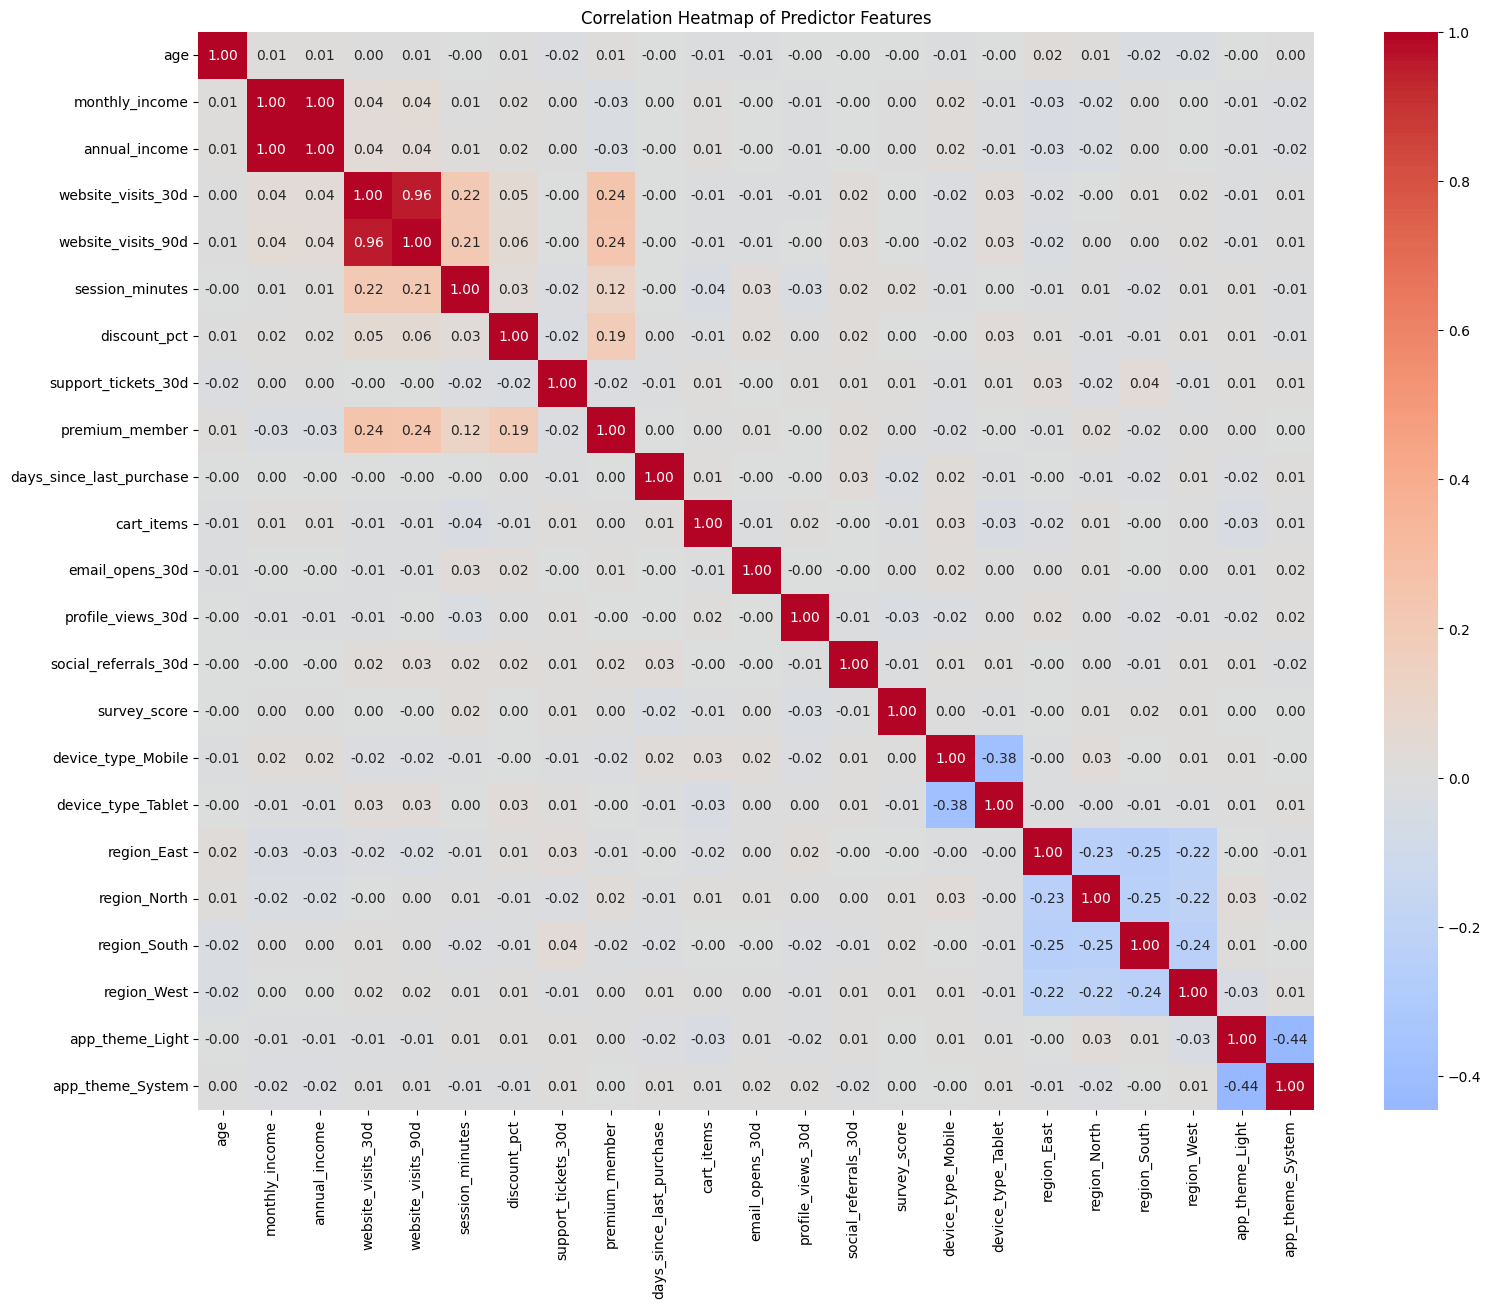

In [ ]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Predictor Features')

plt.show()

In [ ]:
# Calculate correlation matrix
corr_matrix = X_corr.corr()

# Keep only upper triangle
upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

# Convert to DataFrame
corr_pairs = (
    upper
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    'feature_a',
    'feature_b',
    'correlation'
]

corr_pairs= corr_pairs.sort_values(by='correlation', ascending=False)
high_corr_pairs = corr_pairs[corr_pairs['correlation'] >= 0.5]
high_corr_pairs

,feature_a,feature_b,correlation
25,monthly_income,annual_income,0.999377
73,website_visits_30d,website_visits_90d,0.955436


these two pairs have extremely high correlations
- `monthly_income` and `annual_income` = 0.999
- `website_visits_30d` and `website_visits_90d` = 955

In [ ]:
corr_pairs.sort_values(by='correlation', ascending=False).head(10)

,feature_a,feature_b,correlation
25,monthly_income,annual_income,0.999377
73,website_visits_30d,website_visits_90d,0.955436
77,website_visits_30d,premium_member,0.244886
100,website_visits_90d,premium_member,0.238028
74,website_visits_30d,session_minutes,0.219851
97,website_visits_90d,session_minutes,0.210846
146,discount_pct,premium_member,0.189579
123,session_minutes,premium_member,0.119569
98,website_visits_90d,discount_pct,0.055536
75,website_visits_30d,discount_pct,0.054696


### Variance Inflation Factor

In [ ]:
df.head()

,customer_id,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,purchased
0,CUST00001,49,6720.01,79776.46,3,10,9.00,20.7,1,1,39.25,2,2,0,1,1,9,0,0,0,1,0,0,0,1,0
1,CUST00002,67,2992.49,34566.70,2,9,23.83,15.7,1,0,72.32,3,3,2,2,3,13,1,0,0,0,1,0,0,0,1
2,CUST00003,34,1904.54,22862.84,1,5,21.83,10.7,1,0,109.46,6,6,4,1,6,11,1,0,1,0,0,0,1,0,0
3,CUST00004,73,5105.71,61347.30,2,10,7.53,15.0,0,1,6.57,2,5,3,1,7,18,1,0,0,0,0,0,0,0,0
4,CUST00005,60,4323.43,51861.38,6,20,16.49,8.3,0,1,171.29,4,4,0,0,9,11,1,0,0,0,0,1,0,1,0


In [ ]:
df.columns

Index(['customer_id', 'age', 'monthly_income', 'annual_income',
       'website_visits_30d', 'website_visits_90d', 'session_minutes',
       'discount_pct', 'support_tickets_30d', 'premium_member',
       'days_since_last_purchase', 'cart_items', 'email_opens_30d',
       'profile_views_30d', 'social_referrals_30d', 'survey_score',
       'preferred_contact_hour', 'device_type_Mobile', 'device_type_Tablet',
       'region_East', 'region_North', 'region_South', 'region_West',
       'app_theme_Light', 'app_theme_System', 'purchased'],
      dtype='str')

#### monthly_income 

In [ ]:
# features 
X_month_income = df[
    ['age',
    'annual_income',
    'website_visits_30d', 
    'website_visits_90d', 
    'session_minutes',
    'discount_pct', 
    'support_tickets_30d', 
    'premium_member',
    'days_since_last_purchase', 
    'cart_items', 
    'email_opens_30d',
    'profile_views_30d', 
    'social_referrals_30d', 
    'survey_score',
    'preferred_contact_hour', 
    'device_type_Mobile', 
    'device_type_Tablet',
    'region_East', 
    'region_North', 
    'region_South', 
    'region_West',
    'app_theme_Light', 
    'app_theme_System']
].to_numpy()
# target
y_month_income = df['monthly_income'].to_numpy()

In [ ]:
# adding intercept
ones = np.ones(
    (X_month_income.shape[0], 1)
)

X_month_income_with_intercept = np.hstack(
    (ones, X_month_income)
)

In [ ]:
# training OLS
beta_hat = (
    np.linalg.pinv(
        X_month_income_with_intercept.T @ X_month_income_with_intercept
    ) @ X_month_income_with_intercept.T
    @ y_month_income
)

In [ ]:
# making predictions 
month_income_predictions = X_month_income_with_intercept @ beta_hat

In [ ]:
# calculating residuals
month_income_residuals = y_month_income - month_income_predictions

In [ ]:
# Calculating SSE 
month_income_SSE = np.sum(month_income_residuals ** 2)

# calculating SST 
month_income_mean = np.mean(y_month_income)
month_income_SST = np.sum((y_month_income - month_income_mean) ** 2)

# Calculate  R² 
month_income_Rsquared = 1 - (month_income_SSE / month_income_SST)
month_income_Rsquared

np.float64(0.9987603774415851)

In [ ]:
# calculating Tolerance 
month_income_tolerance = 1 - month_income_Rsquared
month_income_tolerance

np.float64(0.0012396225584149212)

In [ ]:
# calculating VIF 
month_income_VIF = 1 / month_income_tolerance
month_income_VIF

np.float64(806.6971621415785)

Approximately `99.876%` of the variation in monthly_income can be explained linearly by all the other predictors together. Only about `0.124%` of its variation is not explained by those predictors. The VIF is `806.7`, meaning the variance of the estimated coefficient for monthly_income is about `806.7` times larger than it would be if monthly_income were not linearly related to the other predictors. Therefore, monthly_income has a `severe multicollinearity` problem.

#### premium_member

In [ ]:
X_premium_member = df[[
    'age', 
    'monthly_income', 
    'annual_income',
    'website_visits_30d', 
    'website_visits_90d', 
    'session_minutes',
    'discount_pct', 
    'support_tickets_30d', 
    'days_since_last_purchase', 
    'cart_items', 
    'email_opens_30d',
    'profile_views_30d', 
    'social_referrals_30d', 
    'survey_score',
    'preferred_contact_hour', 
    'device_type_Mobile', 
    'device_type_Tablet',
    'region_East', 
    'region_North', 
    'region_South', 
    'region_West',
    'app_theme_Light', 
    'app_theme_System']
].to_numpy()

y_premium_member = df['premium_member'].to_numpy()

In [ ]:
# adding intercept 
ones = np.ones(
    (X_premium_member.shape[0], 1)
)
X_premium_member_with_intercept = np.hstack(
    (ones, X_premium_member)
)


In [ ]:
# training OLS 
premium_member_beta = (
    np.linalg.pinv(
        X_premium_member_with_intercept.T @
        X_premium_member_with_intercept
    ) @ X_premium_member_with_intercept.T 
    @ y_premium_member
)

In [ ]:
# making predictions
premium_member_predictions = X_premium_member_with_intercept @ premium_member_beta

# calculating residuals
premium_member_residuals = y_premium_member - premium_member_predictions

# Unexplained variation
premium_member_SSE = np.sum(premium_member_residuals ** 2)

# Total Variation 
premium_member_mean = np.mean(y_premium_member)
premium_member_SST = np.sum((y_premium_member - premium_member_mean) ** 2)

# Calculate  R² 
premium_member_Rsquared = 1 - (premium_member_SSE / premium_member_SST)
premium_member_Rsquared

np.float64(0.09877258086389129)

In [ ]:
# Tolerance 
premium_member_tolerance = 1 - premium_member_Rsquared
premium_member_tolerance

np.float64(0.9012274191361087)

In [ ]:
premium_member_VIF = 1 / premium_member_tolerance
premium_member_VIF

np.float64(1.1095978426384008)

Approximatelly `9.9%` of the variation in premium_member can be explained linearyly by all the other predictors together. About `90.1%` of variation is not explained by those predictors. The VIF is `1.11`, meaning the vriance of estimated coefficients for premium_meber is about `1.11` times larger than it would be if premium_member were not linearly related to ther other predictors. Therefor, premium_member has not `multicollinearity` problem.

## Large Sample Size

### Checking total observations and class counts

In [ ]:
df.head()

,customer_id,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,purchased
0,CUST00001,49,6720.01,79776.46,3,10,9.00,20.7,1,1,39.25,2,2,0,1,1,9,0,0,0,1,0,0,0,1,0
1,CUST00002,67,2992.49,34566.70,2,9,23.83,15.7,1,0,72.32,3,3,2,2,3,13,1,0,0,0,1,0,0,0,1
2,CUST00003,34,1904.54,22862.84,1,5,21.83,10.7,1,0,109.46,6,6,4,1,6,11,1,0,1,0,0,0,1,0,0
3,CUST00004,73,5105.71,61347.30,2,10,7.53,15.0,0,1,6.57,2,5,3,1,7,18,1,0,0,0,0,0,0,0,0
4,CUST00005,60,4323.43,51861.38,6,20,16.49,8.3,0,1,171.29,4,4,0,0,9,11,1,0,0,0,0,1,0,1,0


In [ ]:
target = 'purchased'

n_total = len(df)

class_counts = df['purchased'].value_counts()
class_prop = df['purchased'].value_counts(normalize=True)

print("Total observations:", n_total)
print("\nClass counts:")
print(class_counts)

print("\nClass proportions:")
print(class_prop)

Total observations: 6200

Class counts:
purchased
0    5350
1     850
Name: count, dtype: int64

Class proportions:
purchased
0    0.862903
1    0.137097
Name: proportion, dtype: float64


### Checking Actual parameters

In [ ]:
X = df.drop(
    columns=['customer_id', 'purchased']
)

n_parameters = X.shape[1]

print(n_parameters)

24


### Calculating a rough Events-per-parameter ratio

In [ ]:
minority_count = class_counts.min()
epv = minority_count / n_parameters
epv

np.float64(35.416666666666664)

There are about `35.6` positive purchase events available per predictor parameter.

# Evaluating Model Performance

In [ ]:
eval_model = SkLogisticRegression(max_iter=5000)

In [ ]:
eval_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
y_predictions = eval_model.predict(X_test)

In [ ]:
y_test.value_counts()

purchased
0    1019
1     181
Name: count, dtype: int64

## Confusion Matrix

In [ ]:
TP = np.sum((y_test == 1) & (y_predictions == 1))
TN = np.sum((y_test == 0) & (y_predictions == 0))
FP = np.sum((y_test == 0) & (y_predictions == 1))
FN = np.sum((y_test == 1) & (y_predictions == 0))


print(F"TP: {TP}")
print(F"TN: {TN}")
print(F"FP: {FP}")
print(F"FN: {FN}")

TP: 7
TN: 1015
FP: 4
FN: 174


Predictions resutls:
- Model predicted correctly `7 of 181`  class 1. 
- Model predicted correctly `1015 of 1019`  class 0.                                                                                                              The main problem is predicting `class 0` almost all the time. 

### Accuracy

In [ ]:
Accuracy = (TP + TN) / (TP + TN + FP + FN)
Accuracy

np.float64(0.8516666666666667)

Since the dataset is imbalanced and 1019 of 1200 observations are class 0, `85%` accuracy looks good.

### Balanced Accuracy

In [ ]:
Balanced_Accuracy = 1/2 * (TP / (TP + FN) + TN / (TN + FP)) 
Balanced_Accuracy

np.float64(0.5173743080368035)

When class 0 and class 1 are given equal importance, the model's average ability to correctly identify the two classes is about `51.7%`.

### Precision

In [ ]:
Precision = TP / (TP + FP)
Precision

np.float64(0.6363636363636364)

When the model actually predicts purchased=1, it is correct about `64%` of the time.

### Recall

In [ ]:
Recall = TP / (TP + FN)
Recall

np.float64(0.03867403314917127)

of all customers who actually purchased, the model found only about `3.9%`

### F1_Score

In [ ]:
F1_score = 2 * ((Precision * Recall) / (Precision + Recall))
F1_score

np.float64(0.07291666666666666)

F1-score = `7.29%` means the model has a very poor balance between precision and recall for the positive class. Although precision is 63.64%, recall is only 3.87%, so the model misses almost all actual positive cases.

# Common Pitfalls

## Common Pitfalls

### Underfitting Model

In [122]:
df.head()

,age,monthly_income,annual_income,website_visits_30d,website_visits_90d,session_minutes,discount_pct,support_tickets_30d,premium_member,days_since_last_purchase,cart_items,email_opens_30d,profile_views_30d,social_referrals_30d,survey_score,preferred_contact_hour,device_type_Mobile,device_type_Tablet,region_East,region_North,region_South,region_West,app_theme_Light,app_theme_System,purchased
0,49,6720.01,79776.46,3,10,9.00,20.7,1,1,39.25,2,2,0,1,1,9,0,0,0,1,0,0,0,1,0
1,67,2992.49,34566.70,2,9,23.83,15.7,1,0,72.32,3,3,2,2,3,13,1,0,0,0,1,0,0,0,1
2,34,1904.54,22862.84,1,5,21.83,10.7,1,0,109.46,6,6,4,1,6,11,1,0,1,0,0,0,1,0,0
3,73,5105.71,61347.30,2,10,7.53,15.0,0,1,6.57,2,5,3,1,7,18,1,0,0,0,0,0,0,0,0
4,60,4323.43,51861.38,6,20,16.49,8.3,0,1,171.29,4,4,0,0,9,11,1,0,0,0,0,1,0,1,0


In [123]:
X = X_stand.copy()
y = df['purchased']

n = len(df)

np.random.seed(42)
incices = np.random.permutation(n)

X_shuffled = X.iloc[incices]
y_shuffled = y.iloc[incices]

X_train = X_shuffled[:int(0.8*n)]
y_train = y_shuffled[:int(0.8*n)]

X_test = X_shuffled[int(0.8*n):]
y_test = y_shuffled[int(0.8*n):]


print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (4800, 24)
Test set size: (1200, 24)


In [124]:
model = SkLogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [125]:
# predicstions
y_train_predictions = model.predict(X_train)
y_test_predictions = model.predict(X_test)

# Train Confusion Matrix
train_TP = np.sum((y_train == 1) & (y_train_predictions == 1))
train_TN = np.sum((y_train == 0) & (y_train_predictions == 0))
train_FP = np.sum((y_train == 0) & (y_train_predictions == 1))
train_FN = np.sum((y_train == 1) & (y_train_predictions == 0))

print("TP:", train_TP)
print("TN:", train_TN)
print("FP:", train_FP)
print("FN:", train_FN)
print("----------------")

# Test Confusion Matrix
test_TP = np.sum((y_test == 1) & (y_test_predictions == 1))
test_TN = np.sum((y_test == 0) & (y_test_predictions == 0))
test_FP = np.sum((y_test == 0) & (y_test_predictions == 1))
test_FN = np.sum((y_test == 1) & (y_test_predictions == 0))

print("TP:", test_TP)
print("TN:", test_TN)
print("FP:", test_FP)
print("FN:", test_FN)

TP: 25
TN: 4156
FP: 19
FN: 600
----------------
TP: 7
TN: 1015
FP: 4
FN: 174


In [126]:
conf_matrix = pd.DataFrame(
    {
        'train':[train_TP, train_TN, train_FP, train_FN],
        'test':[test_TP, test_TN, test_FP, test_FN]
    },
    index=['TP', 'TN', 'FP', 'FN']
)

conf_matrix

,train,test
TP,25,7
TN,4156,1015
FP,19,4
FN,600,174


In [127]:
# Accuracy
train_accuracy = (train_TP + train_TN) / (train_TP + train_TN + train_FP + train_FN)
test_accuracy = (test_TP + test_TN) / (test_TP + test_TN + test_FP + test_FN)

# Balanced Accuracy
train_balanced_accuracy = 1/2 * (train_TP / (train_TP + train_FN) + train_TN / (train_TN + train_FP))
test_balanced_accuracy = 1/2 * (test_TP / (test_TP + test_FN) + test_TN / (test_TN + test_FP))

# Precision
train_precision = train_TP / (train_TP + train_FP)
test_precision = test_TP / (test_TP + test_FP)

# Recall
train_recall = train_TP / (train_TP + train_FN)
test_reacall = test_TP / (test_TP + test_FN)

# F1_score
train_F1 = 2 * ((train_precision * train_recall) / (train_precision + train_recall))
test_F1 = 2 * ((test_precision * test_reacall) / (test_precision + test_reacall))

In [128]:
model_results = pd.DataFrame({
    "train":[train_accuracy, train_balanced_accuracy, train_precision, train_recall, train_F1],
    "test":[test_accuracy, test_balanced_accuracy, test_precision, test_reacall, test_F1]
}, index=['Accuracy', 'Balanced Acccuracy', 'Precision', 'Recall', 'F1 Score'])


model_results

,train,test
Accuracy,0.871042,0.851667
Balanced Acccuracy,0.517725,0.517374
Precision,0.568182,0.636364
Recall,0.040000,0.038674
F1 Score,0.074738,0.072917


Overfitting conclusion: The Logistic Regression model does not show clear overfitting because training and test performance are very similar. Balanced Accuracy is approximately 51.8% on both sets, Recall is approximately 4%, and F1 is approximately 7%. The main problem is not a train-test generalization gap; the model performs poorly at detecting the positive class on both datasets.

The model does not appear to be overfitting because train and test performance are very similar. Its very poor training performance on the positive class suggests possible underfitting, but class imbalance and the default 0.5 classification threshold must be investigated before concluding that the model itself is underfitting.